In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

In [5]:
df_a = pd.read_csv(r'C:\Users\HP\OneDrive\Documents\ProjetRN\Partie2\climat\installation_datasetsA\arkansas_partie2.csv')
df_c =pd.read_csv(r'C:\Users\HP\OneDrive\Documents\ProjetRN\Partie2\Topographie\installationDatasetC\california_partie2.csv')

In [6]:
#Californie
df_a.info()
df_a.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9981 entries, 0 to 9980
Columns: 492 entries, system:index to .geo
dtypes: float64(468), int64(21), object(3)
memory usage: 37.5+ MB


,system:index,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,...,tmin_27,tmin_28,tmin_29,tmin_30,tmin_31,tmin_32,tmin_33,tmin_34,tmin_35,.geo
0,00000000000000000002_0,3493.0,3742.0,4504.0,3782.0,4722.5,5072.0,5876.0,0.0,2652.0,...,17.593515,9.598047,10.387583,3.482919,3.987588,1.064722,3.048181,2.509515,-0.625510,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000000004_0,3232.0,3589.0,5048.0,3738.0,4531.5,4309.0,2739.5,0.0,2602.5,...,17.365000,9.328516,9.948862,3.222497,4.493448,1.713159,3.000497,2.130868,-0.775900,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000007_0,3499.0,3990.0,4514.0,4063.0,5600.5,6008.0,6418.5,4066.0,3660.0,...,17.540781,9.851954,10.366831,3.945154,4.239541,1.224878,2.921228,2.367197,-0.576681,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0000000000000000000a_0,2721.5,3163.5,3634.5,3211.0,3143.0,3247.5,5531.5,0.0,3346.5,...,17.263437,9.744532,10.453989,3.500497,3.118448,0.078394,3.202478,1.546289,-0.656760,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0000000000000000000d_0,3124.5,3498.0,6004.0,3654.0,4527.5,4171.0,3841.0,0.0,2922.0,...,17.808360,11.625879,10.461802,4.783701,5.389932,2.385034,3.502451,2.999414,1.440897,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [7]:

df_c.info()
df_c.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Columns: 492 entries, system:index to .geo
dtypes: float64(468), int64(21), object(3)
memory usage: 37.5+ MB


,system:index,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,...,tmin_27,tmin_28,tmin_29,tmin_30,tmin_31,tmin_32,tmin_33,tmin_34,tmin_35,.geo
0,00000000000000001e6f_0,2699.0,2817.0,3821.5,3712.0,3836.5,2813.5,2718.0,2605.5,2493.5,...,12.242609,9.183222,7.617715,6.476327,4.621835,5.181634,5.545556,1.997690,-0.966376,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000001bac_0,3440.5,3722.0,4318.5,3930.0,3993.5,3153.5,2916.0,2795.5,2725.0,...,11.018778,6.771982,7.741830,8.491098,6.230310,6.417551,7.063119,2.736459,-0.351599,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000207_0,3859.0,4026.5,4694.0,4181.0,4405.5,3322.0,2563.5,2319.0,2290.5,...,11.114359,5.405939,5.387247,10.058435,6.693216,3.200113,4.662454,0.045053,-0.307822,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,000000000000000002a9_0,3244.0,3525.0,4279.0,4470.0,4784.0,4430.5,1125.0,3495.0,2053.5,...,12.787531,9.429316,7.855432,8.122812,4.489023,5.597086,7.029199,1.909525,-1.413641,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,000000000000000002fe_0,1075.5,1097.0,2832.5,1999.0,1204.0,1186.0,1495.0,1881.5,1927.5,...,13.156672,9.347971,7.044809,9.204844,5.574960,3.875894,6.093225,1.854898,0.454980,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [ ]:
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',

    'crop_label',

    'constant','elevation',

    'crop_name'
]

df_a = df_a[nouvel_ordre]
df_c = df_c[nouvel_ordre]




In [10]:
df_a.head()


,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,constant,elevation,crop_name
0,1578.0,1900.0,2305.0,2684.0,2891.0,3028.0,3138.0,3226.0,3493.0,2851.0,...,3395.0,3637.0,3648.0,3763.0,3708.0,3046.0,1,34,51,Corn
1,1561.0,1870.0,1932.0,2632.5,3458.0,3638.5,3844.0,3850.0,3232.0,2393.0,...,2671.0,2793.0,2970.0,2998.0,3206.0,2498.0,1,31,58,Corn
2,1696.0,1998.0,2342.0,2668.0,2778.0,2927.0,3066.0,3056.0,3499.0,2888.0,...,3458.0,3657.0,3918.0,3935.0,4352.0,3365.0,1,24,55,Corn
3,1419.0,1670.0,1794.0,2180.0,2701.0,2922.0,3335.0,3189.5,2721.5,2077.5,...,2889.5,3076.5,3518.0,3155.0,3076.5,2387.5,1,34,71,Corn
4,1531.0,1761.0,2069.5,2296.5,2544.5,2654.5,2821.0,2827.5,3124.5,2602.0,...,3365.0,3614.5,3821.0,3747.0,3384.0,2620.0,1,24,47,Corn


In [11]:
df_c.head()

,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,constant,elevation,crop_name
0,1258.0,1433.0,1644.0,1710.0,1758.0,1822.0,1886.0,1933.0,2699.0,2371.0,...,2236.0,2306.0,2390.0,2503.0,3119.0,2423.0,1,24,45,Others
1,1570.0,1787.0,2083.0,2192.5,2245.5,2362.5,2453.5,2515.0,3440.5,3132.0,...,2543.0,2699.0,2820.0,2858.0,3535.0,2866.0,1,34,42,Others
2,1575.0,1709.0,1946.5,2051.5,2046.0,2148.0,2394.0,2388.5,3859.0,3823.0,...,5513.0,6563.0,6900.0,6602.5,3912.5,3260.5,1,34,89,Others
3,1532.0,1800.0,2036.0,2124.0,2212.0,2315.0,2466.0,2422.0,3244.0,2884.0,...,2972.0,3052.0,3306.0,3397.0,2895.0,2029.0,3,34,43,Rice
4,1466.0,1600.5,1695.5,1781.5,1528.5,1529.5,1499.5,1352.5,1075.5,1065.5,...,2161.0,2073.0,2148.0,1917.0,1845.0,1647.0,3,34,26,Rice


In [13]:
df_a['crop_name'].value_counts()



crop_name
Soybeans    4680
Rice        2341
Corn        1501
Cotton       794
Others       665
Name: count, dtype: int64

In [14]:
df_c['crop_name'].value_counts()


crop_name
Others        3580
Rice          2021
Grapes        2010
Alfalfa        964
Almonds        793
Pistachios     628
Name: count, dtype: int64

In [15]:
df_a['crop_label'].value_counts()


crop_label
5      4680
3      2341
1      1501
2       794
176     553
61       51
121      24
190      12
122       7
141       5
37        4
123       4
10        2
152       1
143       1
26        1
Name: count, dtype: int64

In [16]:
df_c['crop_label'].value_counts()


crop_label
176    3257
69     2052
3      2037
36      974
75      783
204     640
61      208
1        45
Name: count, dtype: int64

In [17]:
map = folium.Map(location=[df_a['latitude'].mean(), df_a['longitude'].mean()], zoom_start=10)
for i in range(len(df_a)):
    folium.CircleMarker(
        location=[df_a.iloc[i]['latitude'],df_a.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 
map = folium.Map(location=[df_a['latitude'].mean(), df_a['longitude'].mean()], zoom_start=10)
for i in range(len(df_a)):
    folium.CircleMarker(
        location=[df_a.iloc[i]['latitude'],df_a.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 

KeyError: 'latitude'

In [18]:
#Arkansas

In [19]:
print(df_a.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [20]:
#separer x et y
df_a_x = df_a.drop(columns=['crop_label','crop_name'])
X_a = df_a_x.values
df_a_y =df_a[['crop_name','crop_label']]
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [21]:
#reshape
X_time = df_a_x[[col for col in df_a_x.columns if '_T' in col]].values
X_time = X_time.reshape(-1, 36, 10)
X_static = df_a_x[['elevation', 'constant']].values

#normalisation
X_max = X_time.max(axis=(0, 1), keepdims=True)
with np.errstate(invalid='ignore', divide='ignore'):
    X_time = np.where(X_max == 0, 0, X_time / X_max)
X_static = X_static / X_static.max(axis=0)


In [22]:
mask_time = (X_time != 0).astype(float)


In [23]:
#Split

X_time_train, X_time_test, X_static_train, X_static_test, \
y_train, y_test, mask_train, mask_test = train_test_split(
    X_time,
    X_static,
    y_a,
    mask_time,
    test_size=0.85,
    stratify=y_a,
    random_state=42
)

X_time_train, X_time_val, X_static_train, X_static_val, \
y_train, y_val, mask_train, mask_val = train_test_split(
    X_time_train,
    X_static_train,
    y_train,
    mask_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [24]:
#Le CNN
def CNNBlock(x):
    shortcut = x
    dim = x.shape[-1]

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])  # shortcut connection
    x = layers.ReLU()(x)
    return x

In [25]:
#Transformer
def TransformerBlock(x, num_heads=5):
    dim = x.shape[-1]

    # Multi-head attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed Forward
    ff = layers.Dense(dim, activation='relu')(x)
    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

In [26]:
def ALPE(x, mask):
    
    x = layers.Multiply()([x, mask])

    x = layers.Conv1D(filters=x.shape[-1], kernel_size=3, padding='same')(x)

    
    C = x.shape[-1]
    
    
    gamma, b = 2, 1
    import math
    t = int(math.log2(C) / gamma + b / gamma)
    k = t if t % 2 else t + 1  
    
    weights = layers.GlobalAveragePooling1D()(x)         
    weights = layers.Reshape((C, 1))(weights)             
    weights = layers.Conv1D(filters=1, kernel_size=k,
                            padding='same', use_bias=False)(weights) 
    weights = layers.Activation('sigmoid')(weights)        
    weights = layers.Reshape((1, C))(weights)             

    x = layers.Multiply()([x, weights])

    return x

In [27]:
def CTFusion(x):
    cnn_out = CNNBlock(x)
    trans_out = TransformerBlock(x)
    fused = layers.Concatenate()([cnn_out, trans_out])  # (batch, T, 20)
    fused = layers.Dense(x.shape[-1])(fused)            # projection → (batch, T, 10)
    return fused

In [28]:
def build_MCTNet(input_shape=(36, 10), static_shape=(2,), num_classes=5):

    # =========================
    # INPUT TIME SERIES
    # =========================
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = ALPE(inputs, mask)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)

    x = layers.GlobalMaxPooling1D()(x)

    # =========================
    # TOPOGRAPHY (NEW ONLY)
    # =========================
    inputs_static = tf.keras.Input(shape=static_shape)

    x_static = layers.Dense(16, activation='relu')(inputs_static)

    # =========================
    # FUSION (ONLY ADDITION)
    # =========================
    x = layers.Concatenate()([x, x_static])

    # =========================
    # CLASSIFIER (UNCHANGED LOGIC)
    # =========================
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(
        inputs=[inputs, mask, inputs_static],
        outputs=outputs
    )

    return model


In [29]:
model = build_MCTNet(
    input_shape=(36, 10),
    static_shape=(2,),
    num_classes=5
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 36, 10)    │          0 │ input_layer[0][0… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 36, 10)    │        310 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 10, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 1)     │          3 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 1)     │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 10)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 36, 10)    │          0 │ conv1d[0][0],     │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 10)    │        310 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_1[0][0], │
│ (MultiHeadAttentio… │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 10)    │         40 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 36, 10)    │          0 │ multiply_1[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 10)    │         20 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 10)    │        310 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,486 (40.96 KB)

 Trainable params: 10,366 (40.49 KB)

 Non-trainable params: 120 (480.00 B)

In [30]:
model.fit(
    [X_time_train, mask_train, X_static_train],
    y_train,
    validation_data=([X_time_val, mask_val, X_static_val], y_val),
    epochs=200,
    batch_size=32
)


Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.4612 - loss: 1.3815 - val_accuracy: 0.4700 - val_loss: 1.3856
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5572 - loss: 1.1655 - val_accuracy: 0.4767 - val_loss: 1.3378
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6399 - loss: 0.9994 - val_accuracy: 0.4300 - val_loss: 1.2897
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7410 - loss: 0.7905 - val_accuracy: 0.2333 - val_loss: 1.8067
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7828 - loss: 0.6412 - val_accuracy: 0.2500 - val_loss: 1.7139
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8463 - loss: 0.5240 - val_accuracy: 0.2900 - val_loss: 1.8056
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8780 - loss: 0.4343 - val_accuracy: 0.2633 - val_loss: 2.4235
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8997 - loss: 0.3485 - val_accuracy: 0

In [31]:
y_a_pred = model.predict([X_time_test, mask_test, X_static_test])
y_a_pred = y_a_pred.argmax(axis=1)

oa = accuracy_score(y_test, y_a_pred)
f1 = f1_score(y_test, y_a_pred, average='macro')
kappa = cohen_kappa_score(y_test, y_a_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)


266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
OA: 0.9364686468646864
F1: 0.9175602880874862
Kappa: 0.9076561452129832


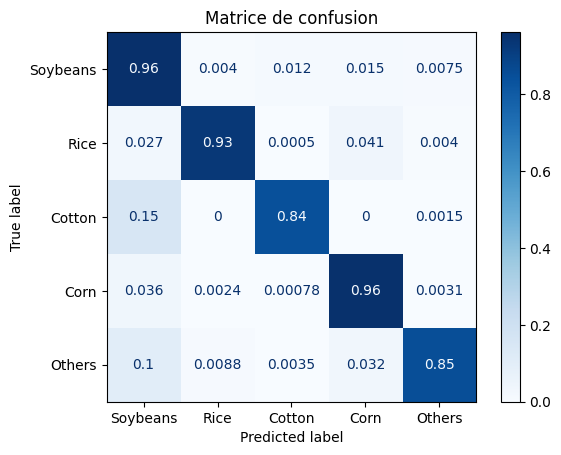

In [32]:
# Confusion Matrix 
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_test, y_a_pred,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

In [33]:
#california
print(df_c.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [36]:
X_c = df_c.drop(columns=['crop_label','crop_name']).values

df_c_y = df_c[['crop_label']].copy()

keep = [3, 36, 69, 75, 204]

# tout le reste → 0
df_c_y['crop_label'] = df_c_y['crop_label'].apply(lambda x: x if x in keep else 0)

# remap
df_c_y['crop_label'] = df_c_y['crop_label'].replace({
    3: 1,
    36: 2,
    69: 3,
    75: 4,
    204: 5
})

y_c = df_c_y['crop_label'].values

print(sorted(np.unique(y_c)))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [37]:

X_time = df_c[[col for col in df_c.columns if '_T' in col]].values
X_time = X_time.reshape(-1, 36, 10)

X_static = df_c[['elevation', 'constant']].values
# =========================
# NORMALISATION TIME
# =========================
X_max = X_time.max(axis=(0, 1), keepdims=True)
X_max[X_max == 0] = 1  
X_time = X_time / X_max

# =========================
# NORMALISATION TOPO
# =========================
X_static = X_static / X_static.max(axis=0)

mask_time = (X_time != 0).astype(float)



In [38]:

X_time_train, X_time_test, \
X_static_train, X_static_test, \
y_train, y_test, \
mask_train, mask_test = train_test_split(
    X_time,
    X_static,
    y_c,
    mask_time,
    test_size=0.82,
    stratify=y_c,
    random_state=42
)

X_time_train, X_time_val, \
X_static_train, X_static_val, \
y_train, y_val, \
mask_train, mask_val = train_test_split(
    X_time_train,
    X_static_train,
    y_train,
    mask_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)


In [41]:
def build_MCTNet_c(input_shape=(36, 10), static_shape=(2,), num_classes=6):

    # =========================
    # INPUT TIME SERIES
    # =========================
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = ALPE(inputs, mask)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)

    x = layers.GlobalMaxPooling1D()(x)

    # =========================
    # TOPOGRAPHY (NEW ONLY)
    # =========================
    inputs_static = tf.keras.Input(shape=static_shape)

    x_static = layers.Dense(16, activation='relu')(inputs_static)

    # =========================
    # FUSION (MINIMAL CHANGE)
    # =========================
    x = layers.Concatenate()([x, x_static])

    # =========================
    # CLASSIFIER
    # =========================
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_c = tf.keras.Model(
        inputs=[inputs, mask, inputs_static],
        outputs=outputs
    )

    return model_c


In [42]:
model_c = build_MCTNet_c(input_shape=(36, 10), static_shape=(2,), num_classes=6)

model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_c.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 36, 10)    │          0 │ input_layer_6[0]… │
│ (Multiply)          │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_16[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 10, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 10, 1)     │          3 │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 10, 1)     │          0 │ conv1d_17[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 10)     │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 36, 10)    │          0 │ conv1d_16[0][0],  │
│ (Multiply)          │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_5[0][0], │
│ (MultiHeadAttentio… │                   │            │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 36, 10)    │          0 │ multiply_5[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 36, 10)    │        310 │ re_lu_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,513 (41.07 KB)

 Trainable params: 10,393 (40.60 KB)

 Non-trainable params: 120 (480.00 B)

In [43]:
model_c.fit(
    [X_time_train, mask_train, X_static_train],
    y_train,
    validation_data=([X_time_val, mask_val, X_static_val], y_val),
    epochs=200,
    batch_size=32
)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 76ms/step - accuracy: 0.4302 - loss: 1.4481 - val_accuracy: 0.3556 - val_loss: 1.6343
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6984 - loss: 0.9913 - val_accuracy: 0.4500 - val_loss: 1.6816
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7901 - loss: 0.6938 - val_accuracy: 0.3583 - val_loss: 1.6759
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8353 - loss: 0.5529 - val_accuracy: 0.5194 - val_loss: 1.3541
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8652 - loss: 0.4575 - val_accuracy: 0.5056 - val_loss: 1.2322
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8888 - loss: 0.3900 - val_accuracy: 0.4083 - val_loss: 1.4054
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8867 - loss: 0.3743 - val_accuracy: 0.5694 - val_loss: 1.2450
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9034 - loss: 0.3359 - val_accuracy: 0

In [44]:
y_c_pred = model_c.predict([X_time_test, mask_test, X_static_test])
y_c_pred = y_c_pred.argmax(axis=1)

oa = accuracy_score(y_test, y_c_pred)
f1 = f1_score(y_test, y_c_pred, average='macro')
kappa = cohen_kappa_score(y_test, y_c_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)


257/257 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
OA: 0.9116750030498963
F1: 0.8784510545723223
Kappa: 0.8855945397935518


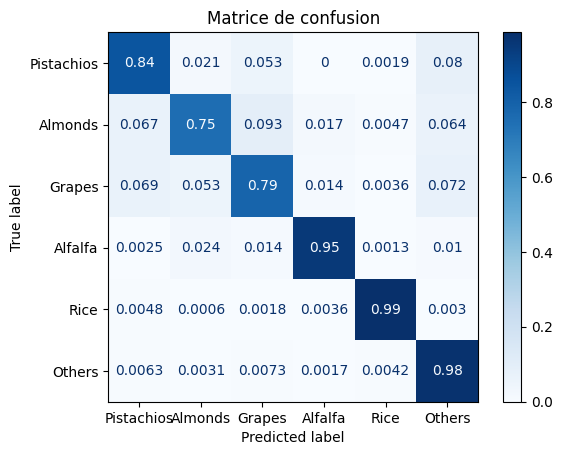

In [45]:
# Confusion Matrix 
labels = ["Pistachios","Almonds","Grapes", "Alfalfa","Rice", "Others"]
cm_c = confusion_matrix(y_test, y_c_pred,labels=[5,4,3,2,1,0])
cm_norm_c = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()